2026-01-04 00:10:28.738075: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-04 00:10:28.738518: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-04 00:10:28.741182: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-04 00:10:28.748120: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767496228.759644  290523 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767496228.76

Usando fashion como dataset


2026-01-04 00:10:31.048599: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "predictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ original_input (InputLayer)     │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_layer (ReshapeLayer)    │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 14, 14, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        31,370 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,570 (197.54 KB)

 Trainable params: 50,378 (196.79 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.5965 - val_loss: 0.5302
Epoch 2/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.4041 - val_loss: 0.3128
Epoch 3/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.3494 - val_loss: 0.2880
Epoch 4/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.3199 - val_loss: 0.2700
Epoch 5/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.2968 - val_loss: 0.2753
Epoch 6/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.2809 - val_loss: 0.2678
Epoch 7/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.2742 - val_loss: 0.2550
Epoch 8/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.2597 - val_loss: 0.2567
Epoch 9/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.2538 - val_loss: 0.2886
Epoch 10/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.2458 - val_loss: 0.2469
Epoch 11/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.2382 - val_loss: 0.2733
Epoch 12/1000
430/4

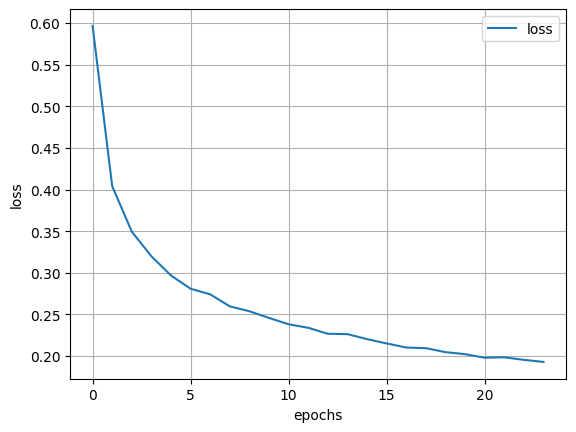

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

import project.loader.load as load
from project.models_definitions import encoder
from project.models_definitions import decoder
from project.models_definitions import predictor
from project.models_definitions.cvae import CVAE 

import matplotlib.pyplot as plt

import tensorflow as tf
from keras.callbacks import EarlyStopping

## parametros
dataset="fashion"
data = load.data(dataset=dataset)
x_train = data["x_train"]
x_val = data["x_val"]
y_train = data["y_train"]
y_val = data["y_val"]
x_test = data["x_test"]
y_test = data["y_test"]

original_dim = 28*28
beta = 1.0

predictor = predictor.build_predictor()

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

predictor.compile(optimizer, loss="categorical_crossentropy")


early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = predictor.fit(
    x=x_train,
    y=y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(x_val, y_val),
    callbacks=[early_stopping],
    verbose=1)

predictor.save("early_stop_fashion.keras")
plt.plot(history.history["loss"], label="loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.grid()
plt.legend()
#plt.savefig(f"loss_vs_epochs_model_int_{intermediate_dim[i]}_lat_{latent_dim[i]}_{dataset}")
plt.show()

modelo entrando recien

In [22]:
import numpy as np

dataset="fashion"
data = load.data(dataset=dataset)
x_train = data["x_train"]
x_val = data["x_val"]
y_train = data["y_train"]
y_val = data["y_val"]
x_test = data["x_test"]
y_test = data["y_test"]

# predicciones
y_pred = predictor.predict(x_test)

# convertir one-hot a etiquetas
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# accuracy manual
accuracy = np.mean(y_pred_labels == y_true_labels)

print(f"Test accuracy (manual): {accuracy:.4f}")


Usando fashion como dataset
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test accuracy (manual): 0.9176


modelo entrenado antes

In [3]:
import numpy as np
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

import project.loader.load as load
from project.models_definitions import encoder
from project.models_definitions import decoder
from project.models_definitions import predictor
from project.models_definitions.cvae import CVAE 

import matplotlib.pyplot as plt

import tensorflow as tf
from keras.callbacks import EarlyStopping

dataset="fashion"
data = load.data(dataset=dataset)
x_train = data["x_train"]
x_val = data["x_val"]
y_train = data["y_train"]
y_val = data["y_val"]
x_test = data["x_test"]
y_test = data["y_test"]

predictor_viejo = load.predictor(dataset=dataset)


# predicciones
y_pred = predictor_viejo.predict(x_test)

# convertir one-hot a etiquetas
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# accuracy manual
accuracy = np.mean(y_pred_labels == y_true_labels)

print(f"Test accuracy (manual): {accuracy:.4f}")


Usando fashion como dataset
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Test accuracy (manual): 0.8965


# Predictor a secas


In [ ]:
import os
import random
import numpy as np
import tensorflow as tf
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from project.loader import Loader

SEED = 1234
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

dataset = "mnist"


data = Loader.data(dataset=dataset)
predictor = Loader.predictor(dataset=dataset)

x_test = data["x_test"]
x_test_1 = data["x_test_1"]
y_test = data["y_test"]
y_test_1 = data["y_test_1"]

def to_class_indices(y):
    y = np.asarray(y)
    if y.ndim > 1 and y.shape[1] > 1:
        return np.argmax(y, axis=1)
    return y.reshape(-1)

def top2_pair_accuracy(predictor, x1, x2, y1, y2, alpha_mix=0.5):
    x1 = x1.astype(np.float32)
    x2 = x2.astype(np.float32)

    mixed = alpha_mix * x1 + (1.0 - alpha_mix) * x2
    probs = predictor(mixed, training=False).numpy()

    top2_idx = np.argsort(probs, axis=1)[:, -2:]
    top2_idx = top2_idx[:, ::-1]  # mejor, segundo mejor

    top2_probs = np.take_along_axis(probs, top2_idx, axis=1)

    y1_idx = to_class_indices(y1)
    y2_idx = to_class_indices(y2)

    both_correct = []
    for i, (label1, label2) in enumerate(zip(y1_idx, y2_idx)):
        top2_set = set(top2_idx[i].tolist())
        both_correct.append((label1 in top2_set) and (label2 in top2_set))

    accuracy_both = np.mean(both_correct)

    return {
        "accuracy_both": accuracy_both,
        "top2_indices": top2_idx,
        "top2_probs": top2_probs,
        "both_correct": np.array(both_correct, dtype=np.bool_),
    }

n_images = 1000

results = top2_pair_accuracy(
    predictor,
    x_test[:n_images],
    x_test_1[:n_images],
    y_test[:n_images],
    y_test_1[:n_images],
)

print("Top-2 accuracy para identificar ambas clases:", results["accuracy_both"])
print("Top-2 índices por imagen:\n", results["top2_indices"])


Usando mnist como dataset
Top-2 accuracy para identificar ambas clases: 0.541
Top-2 índices por imagen:
 [[7 2]
 [0 2]
 [6 1]
 ...
 [0 3]
 [8 9]
 [9 8]]
Top-2 probabilidades por imagen:
 [[7.3497838e-01 2.6424825e-01]
 [9.0871501e-01 9.1077551e-02]
 [9.2519253e-01 2.8678887e-02]
 ...
 [9.0671772e-01 5.6619726e-02]
 [9.9984741e-01 9.6903896e-05]
 [5.4584426e-01 2.9587439e-01]]


/home/galsan/Desktop/tesis/CROP_1/.venv/lib/python3.11/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['original_input']
Received: inputs=Tensor(shape=(1000, 784))
  warnings.warn(msg)


In [ ]:
n_images=10
y1_idx = to_class_indices(y_test[:n_images])
y2_idx = to_class_indices(y_test_1[:n_images])

mixed = 0.5 *   x_test[:n_images] + (1.0 - 0.5) *   x_test_1[:n_images]

predictor = Loader.predictor(dataset=dataset)

probs = np.argsort(predictor.predict(mixed))
print("probs ",probs)
print("y1_indx ",y1_idx)
print("y2_indx ", y2_idx)






1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
probs  [[6 5 4 9 1 0 8 3 2 7]
 [5 7 4 9 3 8 1 6 2 0]
 [9 7 2 0 3 5 8 4 1 6]
 [7 4 1 5 9 3 2 6 8 0]
 [2 1 0 5 6 3 7 8 4 9]
 [0 6 5 4 9 7 2 3 1 8]
 [5 0 6 7 3 1 9 4 2 8]
 [7 3 5 0 2 4 1 6 9 8]
 [4 7 1 6 2 0 9 8 5 3]
 [5 1 6 4 3 2 7 0 9 8]]
y1_indx  [7 2 1 0 4 1 4 9 5 9]
y2_indx  [2 0 6 8 9 8 2 6 3 2]


In [43]:
import numpy as np

def compute_top2_pair_accuracy_from_sorted_indices(sorted_indices, y1_idx, y2_idx):
    # sorted_indices ya es el orden de clases de menor a mayor
    top2 = sorted_indices[:, -2:]
    correct = []
    for a, b, top2_row in zip(y1_idx, y2_idx, top2):
        s = set(top2_row.tolist())
        correct.append((a in s) and (b in s))
    return np.mean(correct), np.array(correct, dtype=np.bool_), top2

dataset = "fashion"

data = Loader.data(dataset=dataset)
predictor = Loader.predictor(dataset=dataset)

x_test = data["x_test"]
x_test_1 = data["x_test_1"]
y_test = data["y_test"]
y_test_1 = data["y_test_1"]

n_images = -1
mixed = 0.5 * x_test[:n_images] + 0.5 * x_test_1[:n_images]

predictions = predictor.predict(mixed)          # shape (n_images, n_classes)
sorted_indices = np.argsort(predictions, axis=1)  # cada fila ordena clases de menor a mayor

y1_idx = to_class_indices(y_test[:n_images])
y2_idx = to_class_indices(y_test_1[:n_images])

accuracy, correct_mask, top2 = compute_top2_pair_accuracy_from_sorted_indices(
    sorted_indices, y1_idx, y2_idx
)

print("Top-2 indices por fila:\n", top2)
print("Acierto por caso:", correct_mask.astype(int))
print("Precisión:", accuracy)

Usando fashion como dataset
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Top-2 indices por fila:
 [[9 1]
 [6 2]
 [4 1]
 ...
 [1 3]
 [0 6]
 [4 1]]
Acierto por caso: [1 0 1 ... 1 0 0]
Precisión: 0.41184118411841186


Usando fashion como dataset


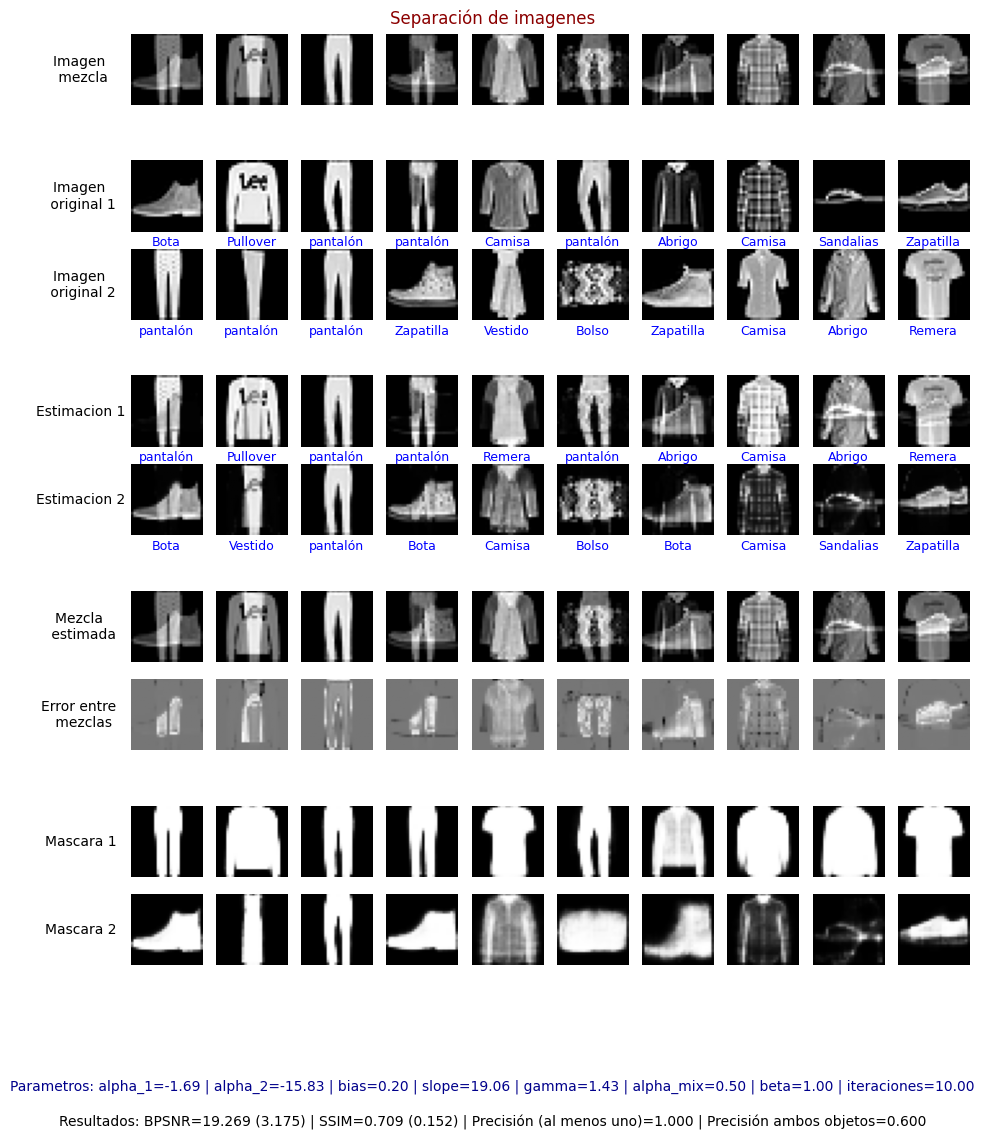

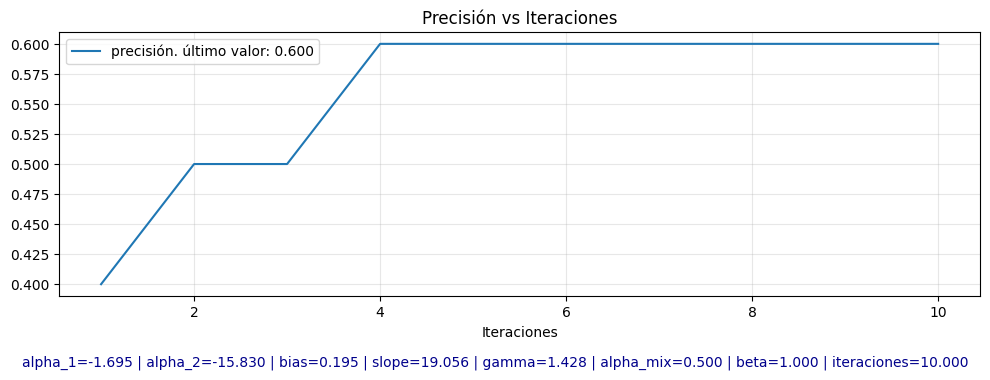

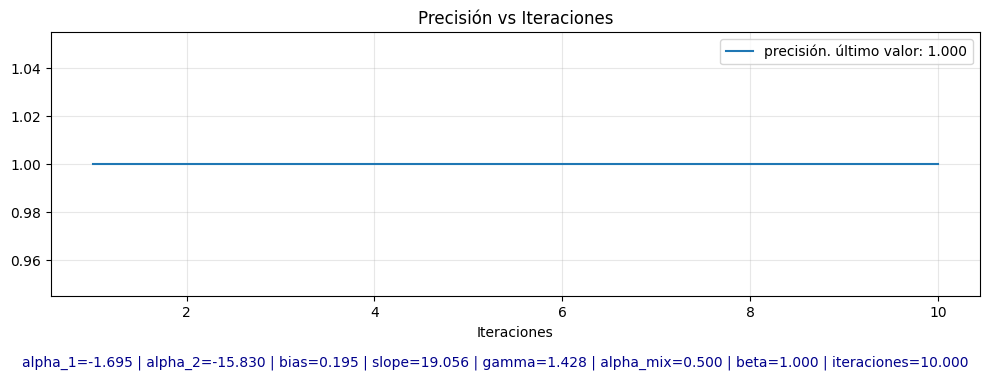

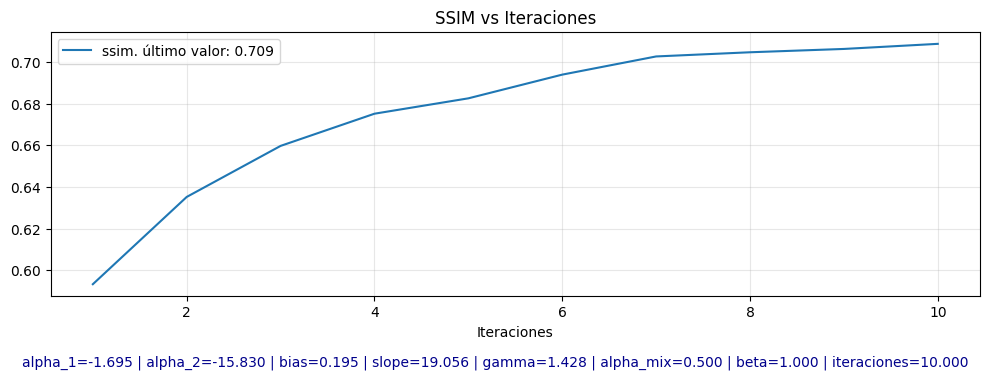

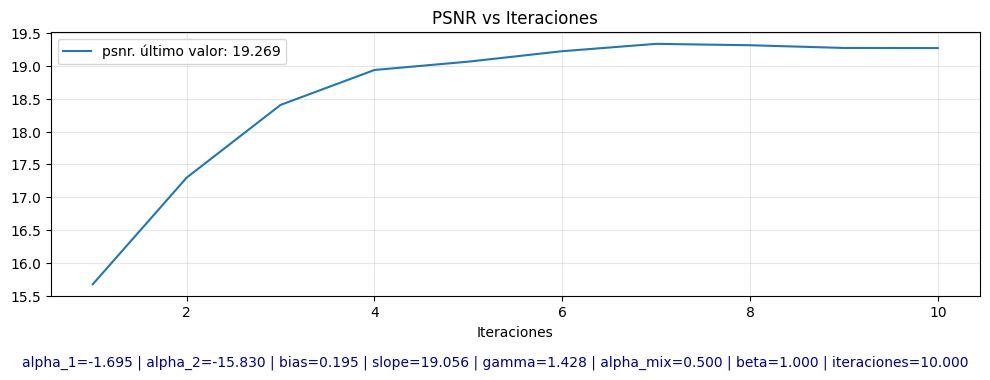


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -1.695
alpha_2     : -15.830
bias        : 0.195
slope       : 19.056
gamma       : 1.428
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 19.269  std:3.175
mask_bpsnr       : mean: 11.576  std:1.944
ssim             : mean: 0.709  std:0.152
acc_at_least_one : 1.000
acc_both         : 0.600



In [2]:

import os
import random
import numpy as np
import tensorflow as tf
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from project.loader import Loader
from project.CROP.models.crop_base_model import CropBaseModel
from project.custom_layers.sampling import Sampling
import tensorflow as tf


from project.CROP.models.crop2 import Crop2

SEED = 1234 #Semilla
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


ITERATIONS = 10
N_PICTURES = 10

DATASET = "fashion" # minst o fashion
LAT = 256
INTER = 512
cvae = Loader.cvae(inter=INTER,lat=LAT,dataset=DATASET)
data = Loader.data(dataset=DATASET)

predictor = Loader.predictor(dataset=DATASET)

x_test = data["x_test"]
x_test_1 = data["x_test_1"]
y_test = data["y_test"]
y_test_1 = data["y_test_1"]
labels= data["labels"]

c = Crop2(cvae=cvae,predictor=predictor)

acc_both_params={'bias': 0.21716868437244724,
'slope': 19.437646607877017,
 'alpha_1': -0.13863158439804657,
  'alpha_2': -10.463749682840565,
  #'gamma': 0.3,
  #'gamma': 0.84,
  'gamma': 1.5,
  }

p_ssim={'bias': 0.19528577387186155, 'slope': 19.05570493024361, 'gamma': 1.4276756171108946, 'alpha_1': -1.6948545718322112, 'alpha_2': -15.82974942022354}
metrics = c.unmix(
    x_test[:N_PICTURES],
    x_test_1[:N_PICTURES],
    y_test[:N_PICTURES],
    y_test_1[:N_PICTURES],
    iterations=ITERATIONS,
    show_image=True,
    labels=labels,
    params=p_ssim,
    show_all_curves=True
    )


In [ ]:
#optim + sepración
import os
import random
import numpy as np
import tensorflow as tf
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

SEED = 1234

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

from project.loader import Loader
from project.CROP.models.crop3_estimation_correction import Crop3

dataset = "fashion"

lat=64
inter=256
data = Loader.data(dataset=dataset)
predictor = Loader.predictor(dataset=dataset)

x_test = data["x_test"]
x_test_1 = data["x_test_1"]
y_test = data["y_test"]
y_test_1 = data["y_test_1"]


c = Crop3(predictor=predictor,lat=lat,inter=inter,dataset=dataset)

def objective(trial):
#
    #bias = trial.suggest_float("bias", 0.05,0.30)
    #slope = trial.suggest_float("slope", 5,20 )
    #gamma = trial.suggest_float("gamma", 0.1, 0.45)
    #alpha_1= trial.suggest_float("alpha_1", -0.3, -0.05)
    #alpha_2= trial.suggest_float("alpha_2", -30, -5)
# beta = trial.suggest_float("beta",0,1.5)
#####
    bias_e = trial.suggest_float("bias", -1,10)
    slope_e = trial.suggest_float("slope", -0.1,25 )
    gamma = trial.suggest_float("gamma", 0,3 )
    
    n_images=2000
    try:
        metrics = c.unmix(
            x_test[:n_images],
            x_test_1[:n_images],
            y_test[:n_images],
            y_test_1[:n_images],
            params={'bias': 0.21716868437244724,
            'slope': 19.437646607877017,
            'alpha_1': -0.13863158439804657,
            'alpha_2': -10.463749682840565,
            "gamma": gamma,
            "bias_e":bias_e,
            "slope_e":slope_e},                
            iterations=10,
            show_metrics=False
        )
        ssim_mean = float(metrics["ssim"][0])
        recon_bpsnr_mean = float(metrics["recon_bpsnr"][0])
        return ssim_mean, recon_bpsnr_mean

    except Exception as e:
        print(f"Error con gamma={gamma}: {e}")
        return float("-inf"), float("-inf")


import optuna


study = optuna.create_study(directions=["maximize", "maximize"])
study.optimize(objective, n_trials=100)

# Mostramos los mejores resultados
print("\n📊 Mejores hiperparámetros encontrados:")
print(study.best_trials[0].params)
print("Valores objetivo:", study.best_trials[0].values)

#{'gamma': 1.378449424990954} psnr 
#'gamma': 0.11498749766563751

2026-04-22 02:12:32.258144: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-22 02:12:32.258615: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-22 02:12:32.261606: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-22 02:12:32.269126: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776834752.281036 2938956 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776834752.28

Usando fashion como dataset


2026-04-22 02:12:35.147755: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/galsan/Desktop/tesis/CROP_1/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-04-22 02:12:35,338] A new study created in memory with name: no-name-f9181e81-76ba-4fd7-8c9d-a58a34ffe959
[I 2026-04-22 02:12:38,020] Trial 0 finished with values: [0.3965590298175812, 15.731244087219238] and parameters: {'bias': 0.504592870050518, 'slope': 15.219638483618276, 'gamma': 0.8455709829523271}.
[I 2026-04-22 02:12:40,818] Trial 1 finished with values: [0.399624764919281, 15.193432807922363] and parameters: {'bias': 3.7338847142407765, 'slope': 23.320237257561455, 'gamma': 2.7181136205863683}.
[I 2026-04-22 02:12:43,48


📊 Mejores hiperparámetros encontrados:
{'bias': 0.504592870050518, 'slope': 15.219638483618276, 'gamma': 0.8455709829523271}
Valores objetivo: [0.3965590298175812, 15.731244087219238]


# Rangos de valores de las imagenes

2026-05-18 19:24:36.576540: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-18 19:24:36.581673: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-18 19:24:36.624943: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-18 19:24:36.653835: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779143076.702647  737390 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779143076.71

Usando fashion como dataset


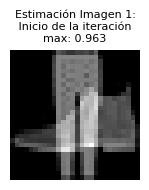

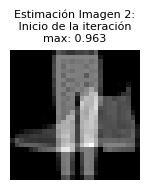

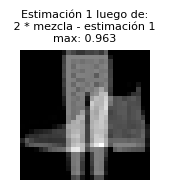

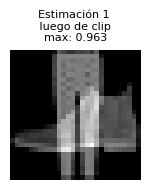

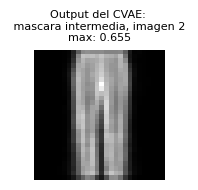

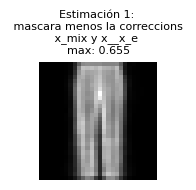

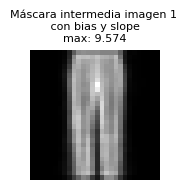

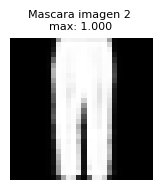

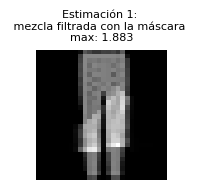

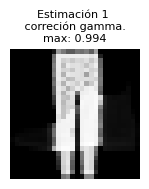

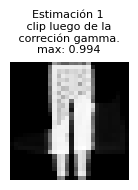


----- estimación de la fuente complementaria -----



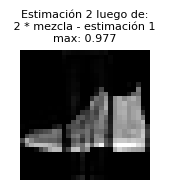

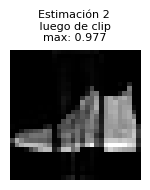

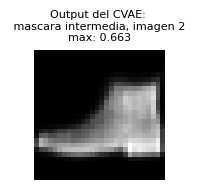

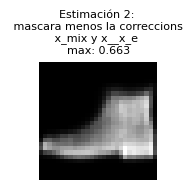

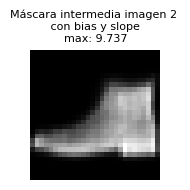

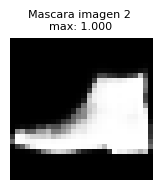

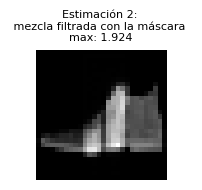

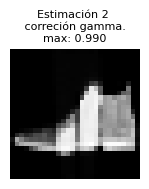

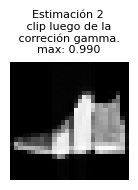

--------------------------------------- fin de la iteración ----------------------------
 
--------------------------------------- inicio de la iteración -------------------------


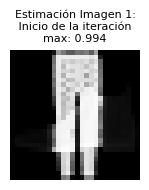

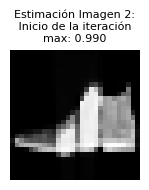

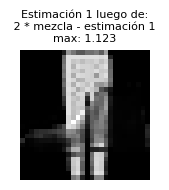

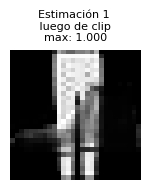

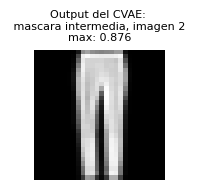

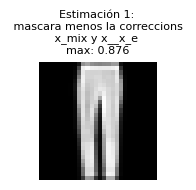

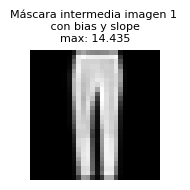

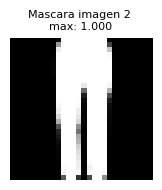

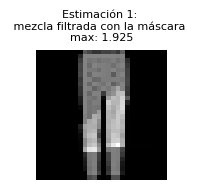

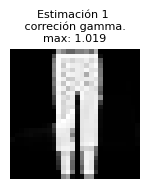

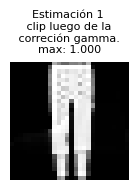


----- estimación de la fuente complementaria -----



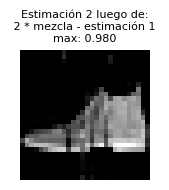

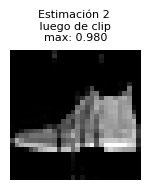

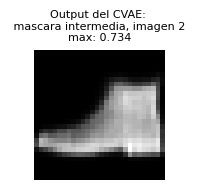

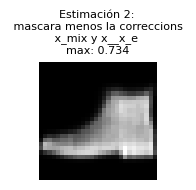

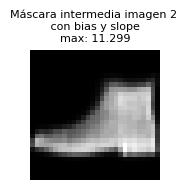

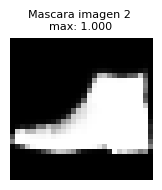

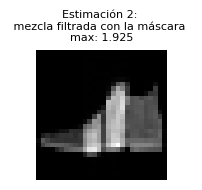

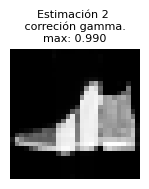

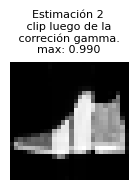

--------------------------------------- fin de la iteración ----------------------------
 
--------------------------------------- inicio de la iteración -------------------------


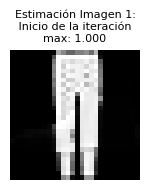

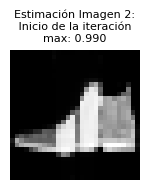

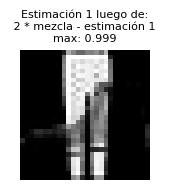

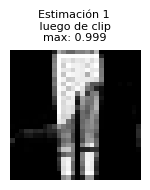

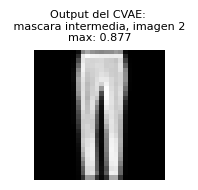

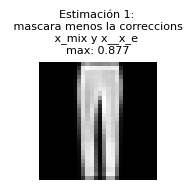

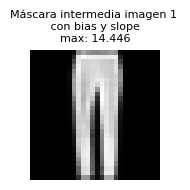

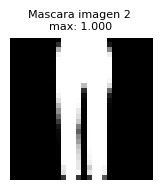

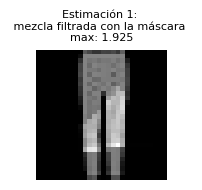

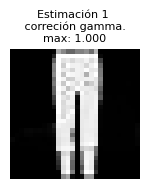

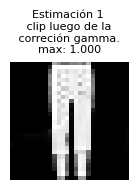


----- estimación de la fuente complementaria -----



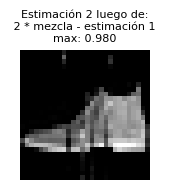

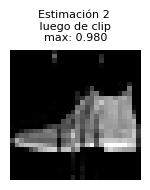

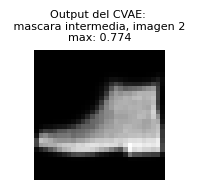

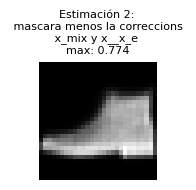

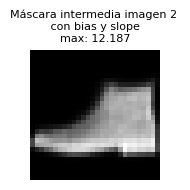

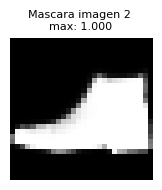

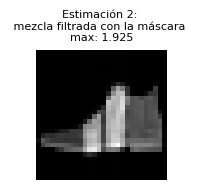

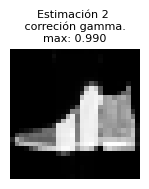

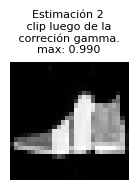

--------------------------------------- fin de la iteración ----------------------------
 
--------------------------------------- inicio de la iteración -------------------------


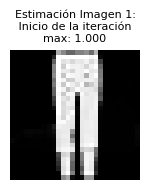

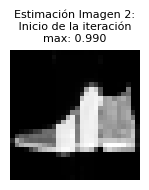

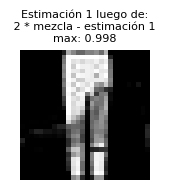

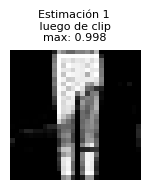

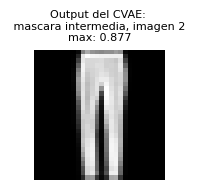

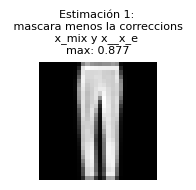

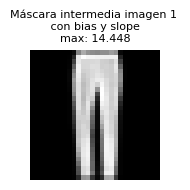

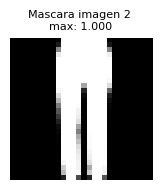

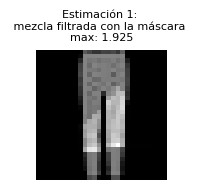

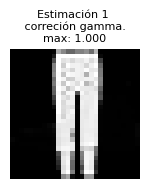

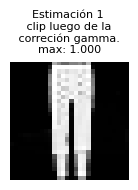


----- estimación de la fuente complementaria -----



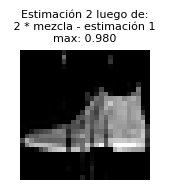

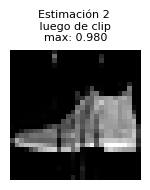

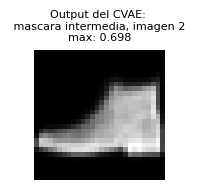

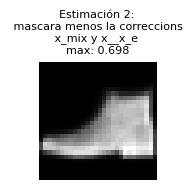

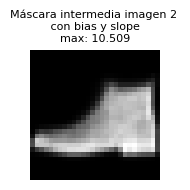

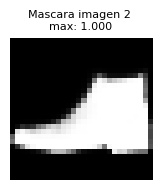

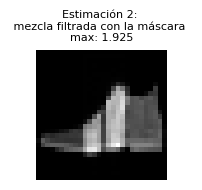

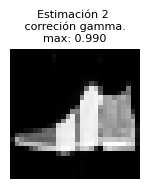

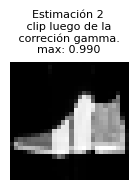

--------------------------------------- fin de la iteración ----------------------------
 
--------------------------------------- inicio de la iteración -------------------------


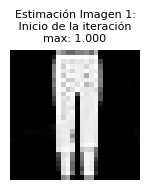

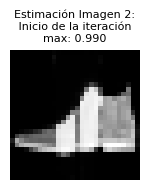

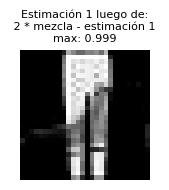

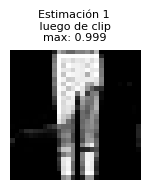

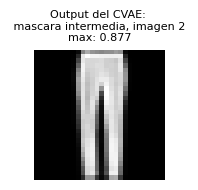

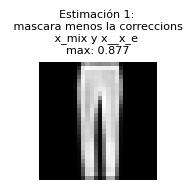

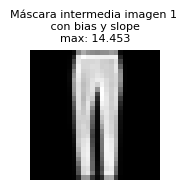

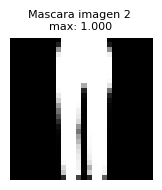

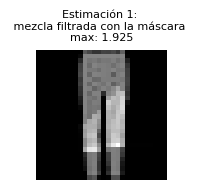

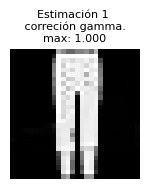

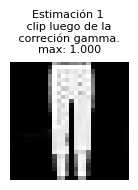


----- estimación de la fuente complementaria -----



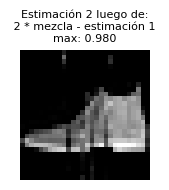

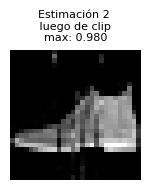

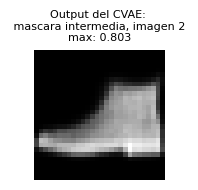

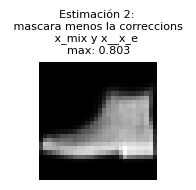

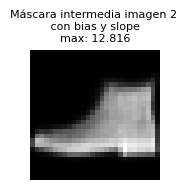

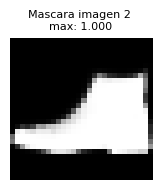

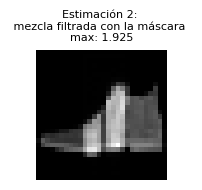

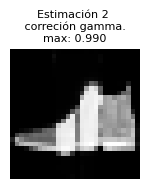

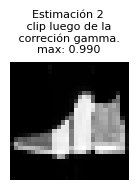

--------------------------------------- fin de la iteración ----------------------------
 
--------------------------------------- inicio de la iteración -------------------------


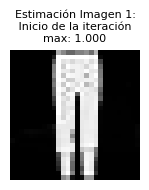

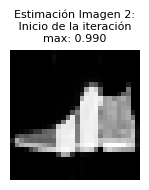

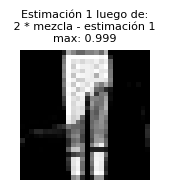

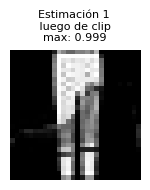

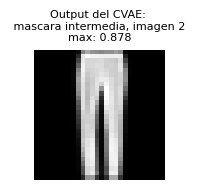

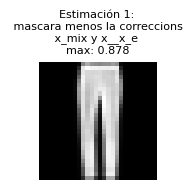

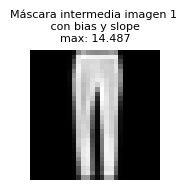

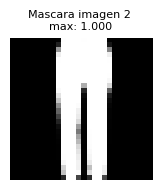

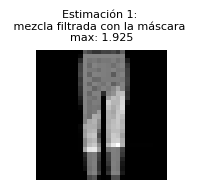

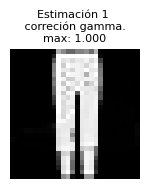

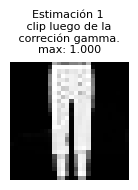


----- estimación de la fuente complementaria -----



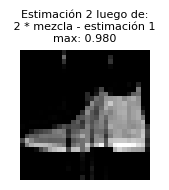

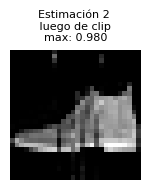

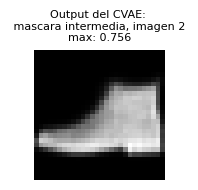

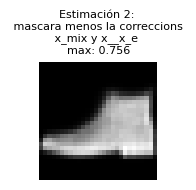

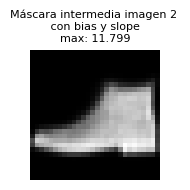

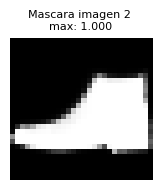

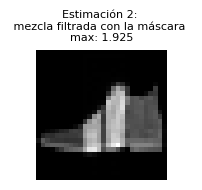

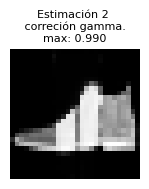

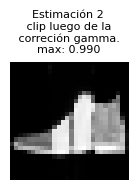

--------------------------------------- fin de la iteración ----------------------------
 
--------------------------------------- inicio de la iteración -------------------------


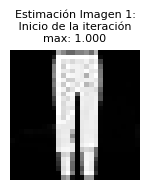

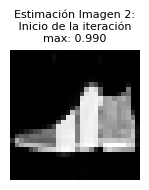

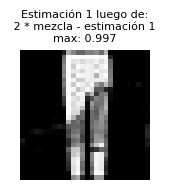

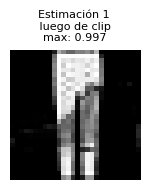

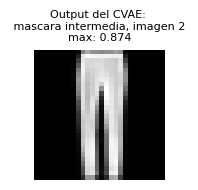

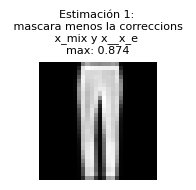

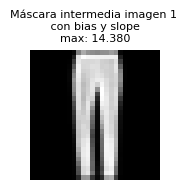

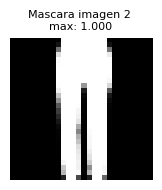

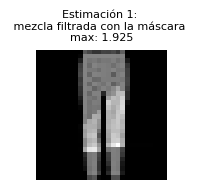

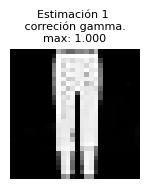

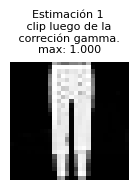


----- estimación de la fuente complementaria -----



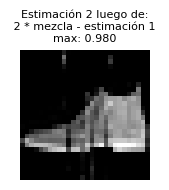

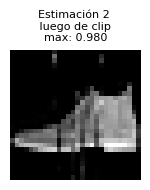

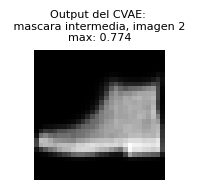

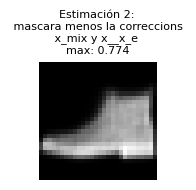

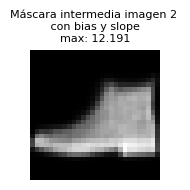

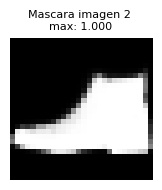

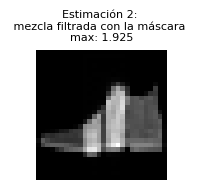

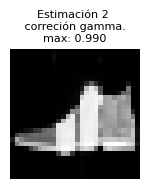

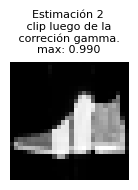

--------------------------------------- fin de la iteración ----------------------------
 
--------------------------------------- inicio de la iteración -------------------------


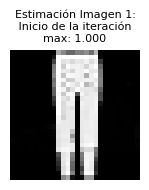

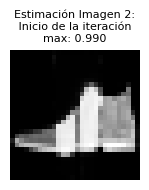

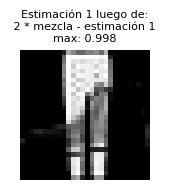

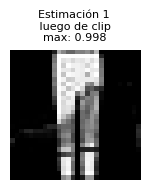

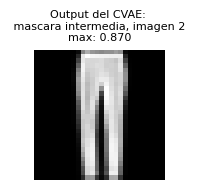

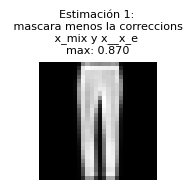

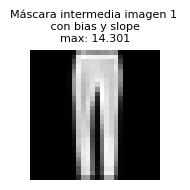

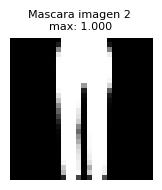

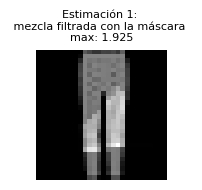

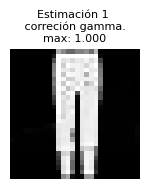

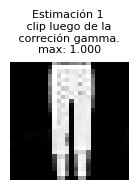


----- estimación de la fuente complementaria -----



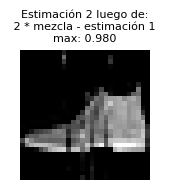

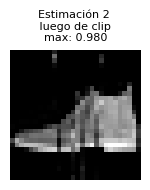

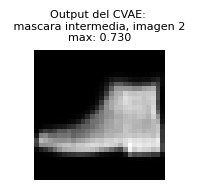

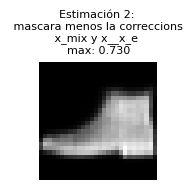

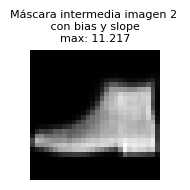

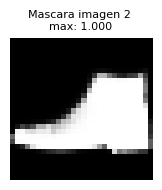

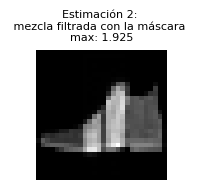

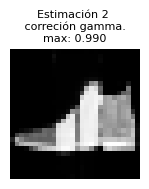

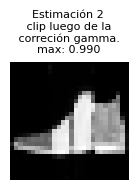

--------------------------------------- fin de la iteración ----------------------------
 
--------------------------------------- inicio de la iteración -------------------------


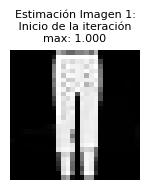

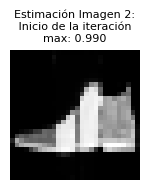

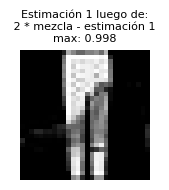

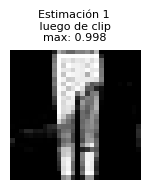

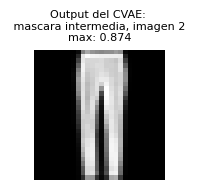

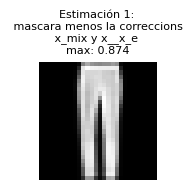

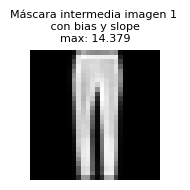

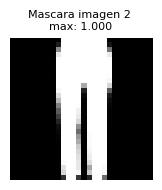

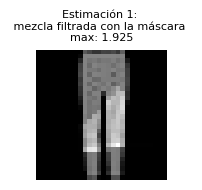

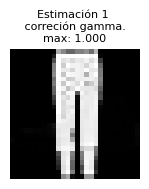

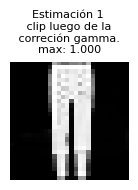


----- estimación de la fuente complementaria -----



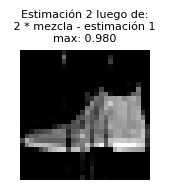

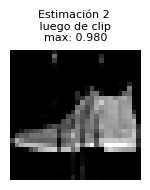

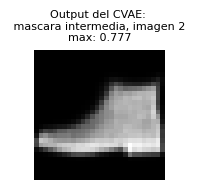

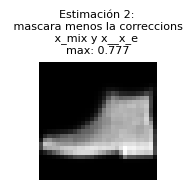

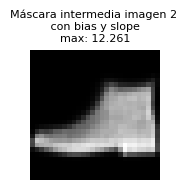

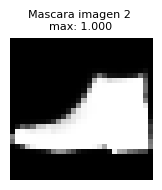

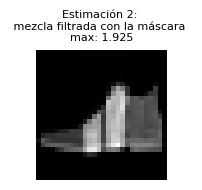

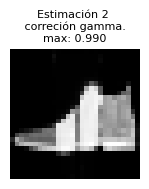

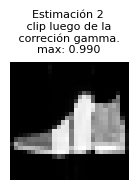

--------------------------------------- fin de la iteración ----------------------------
 
--------------------------------------- inicio de la iteración -------------------------


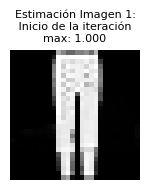

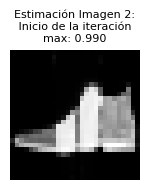

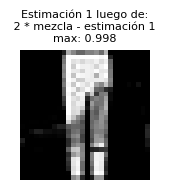

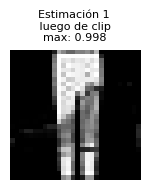

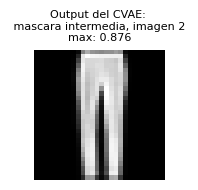

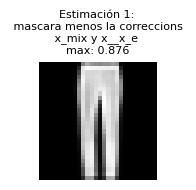

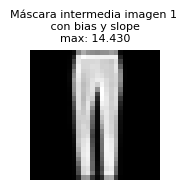

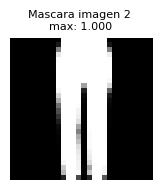

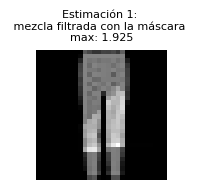

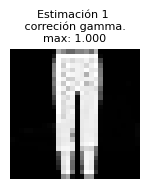

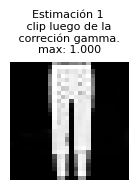


----- estimación de la fuente complementaria -----



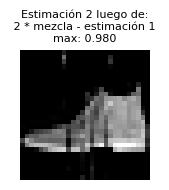

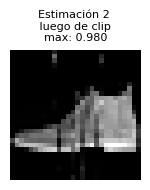

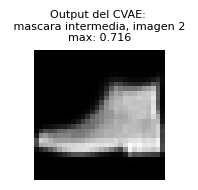

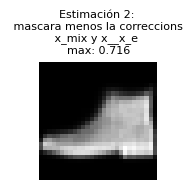

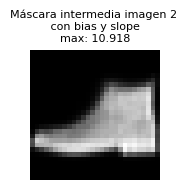

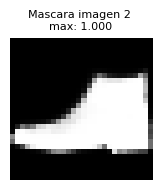

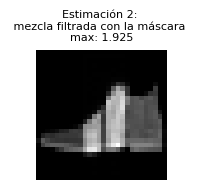

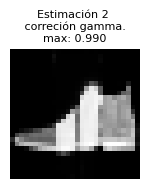

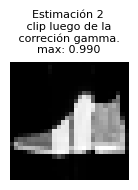

--------------------------------------- fin de la iteración ----------------------------
 
--------------------------------------- inicio de la iteración -------------------------


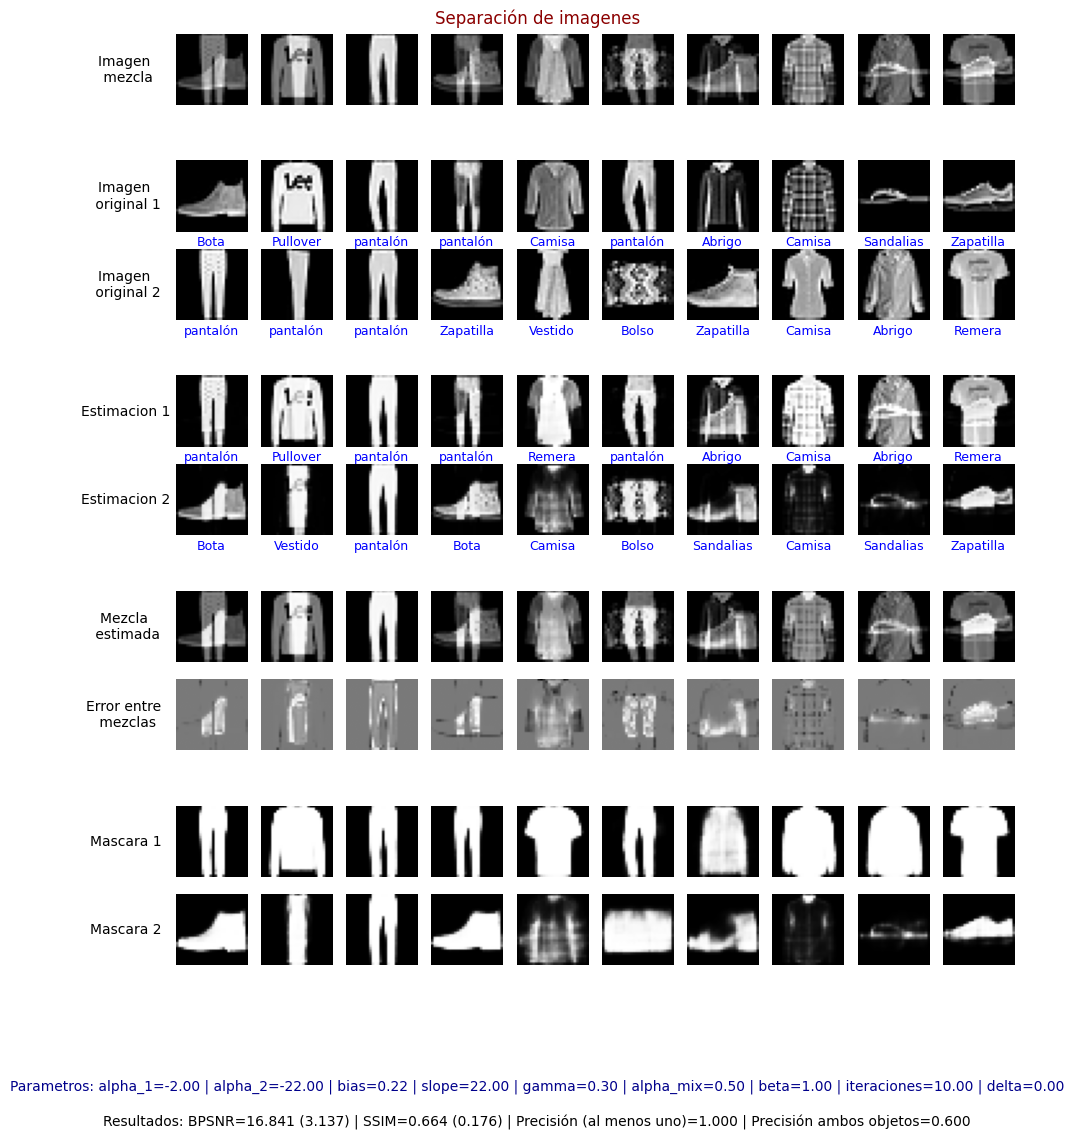

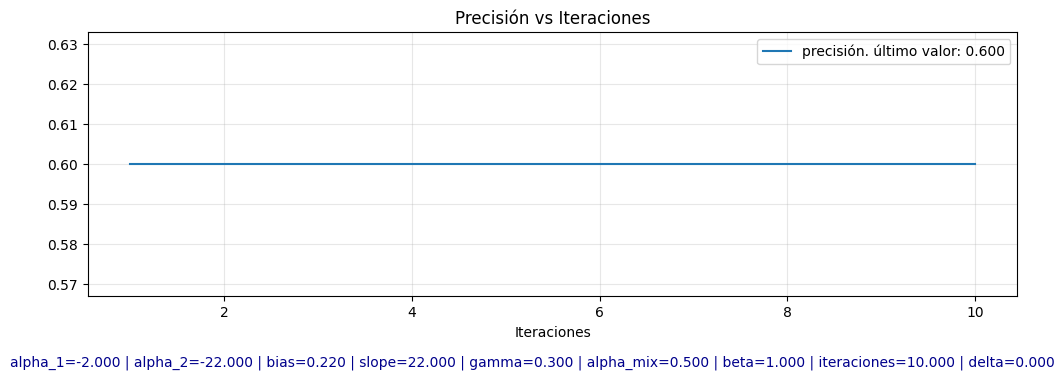

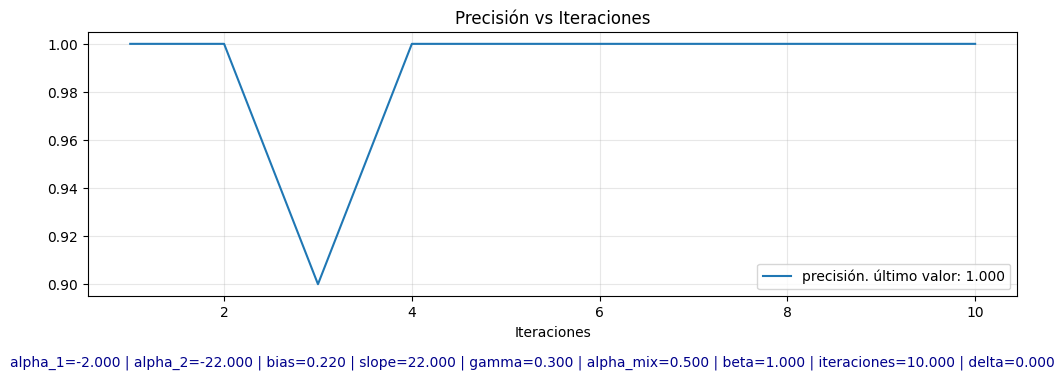

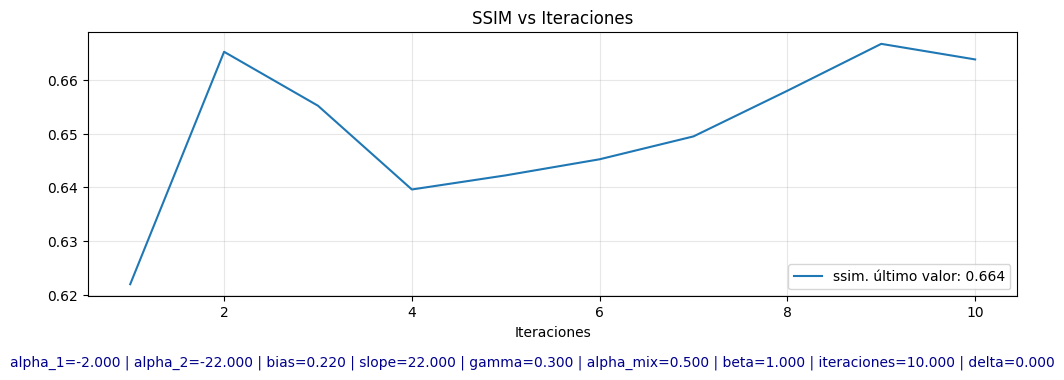

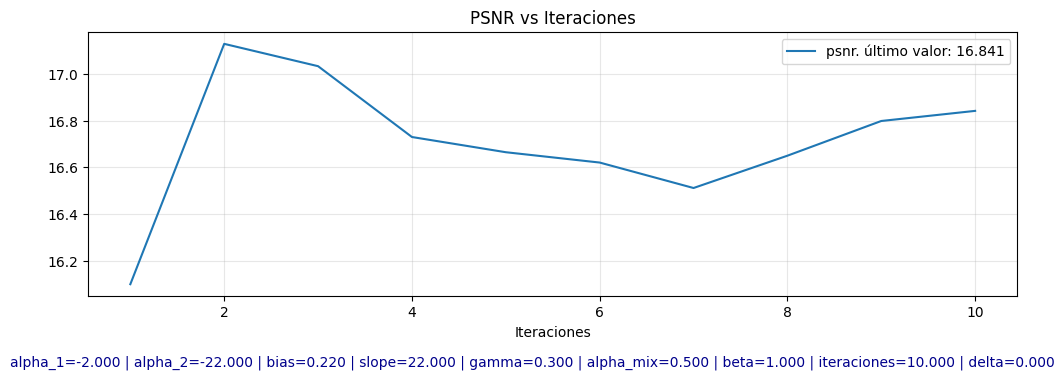


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -2.000
alpha_2     : -22.000
bias        : 0.220
slope       : 22.000
gamma       : 0.300
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 16.841  std:3.137
mask_bpsnr       : mean: 11.759  std:1.993
ssim             : mean: 0.664  std:0.176
acc_at_least_one : 1.000
acc_both         : 0.600



In [ ]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from project.CROP.models.crop_base_model import CropBaseModel
from project.custom_layers.sampling import Sampling
import tensorflow as tf
import random
from project.metrics.metrics import Metrics
import numpy as np
from project.loader import Loader

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from project.CROP.models.crop3_estimation_correction import Crop3


class Crop2(CropBaseModel):


    def _show_images(self, tensor, title="", max_images=1):
        if not hasattr(self, "debug") or not self.debug:
            return

        imgs = tensor

        if isinstance(imgs, tf.Tensor):
            imgs = imgs.numpy()

        # asegurar batch
        if len(imgs.shape) == 1:
            imgs = np.expand_dims(imgs, axis=0)

        n = min(max_images, imgs.shape[0])

        fig, axes = plt.subplots(1, n, figsize=(n * 2, 2))

        if n == 1:
            axes = [axes]

        for i in range(n):
            img = imgs[i]

            # reshape si está plano
            if len(img.shape) == 1:
                img = img.reshape(28, 28)

            max_val = np.max(img)

            axes[i].imshow(img, cmap="gray")
            axes[i].set_title(f"{title} \nmax: {max_val:.3f}", fontsize=8)
            #axes[i].set_title(f"{title}", fontsize=8)
            axes[i].axis("off")

        plt.tight_layout()
        plt.show()

    def filter(self, filter_1, filter_2 ,mixed_input, alpha, bias, slope,n_fuente,delta):

        x_mix_filter_1 =  2 * mixed_input - filter_1
        self._show_images(x_mix_filter_1, f"Estimación {n_fuente} luego de:\n 2 * mezcla - estimación 1")

        x_mix_filter_1 = tf.clip_by_value(x_mix_filter_1, 0, 1)
        self._show_images(x_mix_filter_1, f"Estimación {n_fuente} \n luego de clip")

        condition_encoder = self.predictor(x_mix_filter_1, verbose=0, training=False)
#       print(condition_encoder)
        encoded_imgs = self.cvae.encoder(
            [x_mix_filter_1, condition_encoder], verbose=0, training=0
        )
        
        zz_log_var = encoded_imgs[1] + alpha

        z = Sampling()((encoded_imgs[0], zz_log_var))

        cvae_output = self.cvae.decoder(
            [z, condition_encoder], verbose=0, Training=False
        )
        
        self._show_images(cvae_output, "Output del CVAE: \n mascara intermedia, imagen 2")

        # x__x = (self.source1_estimation+self.source2_estimation)/2
        # x__x_e = x__x - mixed_input
        # mask_source1 = mask_source1 -4.6*(x__x_e) # proto delta
        # self._show_images(x__x_e, f"Error  de mezclas  \n x__x_e - mix")

        
        
        self._show_images(cvae_output, f"Estimación {n_fuente}: \n mascara menos la correccions \n x_mix y x__x_e ")

        mask_source1 = (cvae_output - bias) * slope
        self._show_images(mask_source1, f"Máscara intermedia imagen {n_fuente} \n con bias y slope")

        mask_source1 = tf.sigmoid(mask_source1)
        self._show_images(mask_source1, "Mascara imagen 2")
        

        
        x_mix_filter_1 = 2 * mixed_input * mask_source1
        self._show_images(x_mix_filter_1, f"Estimación {n_fuente}: \n mezcla filtrada con la máscara ")

        x_mix_filter_1 = tf.clip_by_value(x_mix_filter_1, 0, 1) # raro.
        # self._show_images(x_mix_filter_1, f"Estimación {n_fuente} \n luego de clip")
        x_mix_filter_1 = x_mix_filter_1 -(x_mix_filter_1-cvae_output)*delta

        return x_mix_filter_1, mask_source1, condition_encoder



    def decode(self):
        alpha_1 = self.model_params["alpha_1"]
        alpha_2 = self.model_params["alpha_2"]
        beta = self.model_params["beta"]
        bias = self.model_params["bias"]
        slope = self.model_params["slope"]
        gamma = self.model_params["gamma"]
        delta = self.model_params["delta"]

        self._show_images(self.source1_estimation, "Estimación Imagen 1:\n Inicio de la iteración")
        self._show_images(self.source2_estimation, "Estimación Imagen 2:\n Inicio de la iteración")
        #self._show_images(self.mix_input,"Imagen mezcla.")
        reconstructed_source1, mask_source1, predictions_1 = (
            self.filter(self.source2_estimation,self.source1_estimation ,self.mixed_input, alpha_2, bias, slope,1,delta)
        )

        self.source1_estimation = reconstructed_source1
        self.mask1 = mask_source1
        self.predictions1 = predictions_1
        self.model_params["alpha_2"] = alpha_2 * beta

        x__x = (self.source1_estimation + self.source2_estimation) / 2
        x__x_e = x__x - self.mixed_input
        

        self.source1_estimation = self.source1_estimation - (x__x_e * gamma)

        self._show_images(
            self.source1_estimation,
            "Estimación 1 \n correción gamma."
        )

        self.source1_estimation = tf.clip_by_value(self.source1_estimation, 0, 1)

        self._show_images(self.source1_estimation, "Estimación 1 \n clip luego de la \n correción gamma.")

        print("\n----- estimación de la fuente complementaria -----\n")

        reconstructed_source2, mask_source2, predictions_2 = (
            self.filter(reconstructed_source1, self.source1_estimation ,self.mixed_input, alpha_1, bias, slope,2,delta)
        )

        self.source2_estimation = reconstructed_source2
        self.mask2 = mask_source2
        self.predictions2 = predictions_2
        self.model_params["alpha_1"] = alpha_1 * beta

        x__x = (self.source1_estimation + self.source2_estimation) / 2
        x__x_e = x__x - self.mixed_input

        self.source2_estimation = self.source2_estimation - (x__x_e * gamma)

        self._show_images(
            self.source2_estimation,
            "Estimación 2 \n correción gamma."
        )

        self.source2_estimation = tf.clip_by_value(self.source2_estimation, 0, 1)

        self._show_images(self.source2_estimation, "Estimación 2 \n clip luego de la \n correción gamma.")

        print("--------------------------------------- fin de la iteración ----------------------------")
        print(" ")
        print("--------------------------------------- inicio de la iteración -------------------------")
        


SEED = 1234 #Semilla
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


ITERATIONS = 10
N_PICTURES = 10

DATASET = "fashion" # mnist o fashion
LAT = 64
INTER = 128
cvae = Loader.cvae(inter=INTER,lat=LAT,dataset=DATASET)
data = Loader.data(dataset=DATASET)

predictor = Loader.predictor(dataset=DATASET)

x_test = data["x_test"]
x_test_1 = data["x_test_1"]
y_test = data["y_test"]
y_test_1 = data["y_test_1"]
labels= data["labels"]



c = Crop2(cvae=cvae,predictor=predictor)
c.debug = True 


metrics = c.unmix(
    x_test[:N_PICTURES],
    x_test_1[:N_PICTURES],
    y_test[:N_PICTURES],
    y_test_1[:N_PICTURES],
    iterations=ITERATIONS,
    show_image=True,
    labels=labels,
    params={"gamma":0.3, "delta":0},
    show_all_curves=True
    )








In [6]:
np.max(x_test[0])

np.float32(1.0)

## testo con delta

Usando fashion como dataset

----- estimación de la fuente complementaria -----

--------------------------------------- fin de la iteración ----------------------------
 
--------------------------------------- inicio de la iteración -------------------------

----- estimación de la fuente complementaria -----

--------------------------------------- fin de la iteración ----------------------------
 
--------------------------------------- inicio de la iteración -------------------------

----- estimación de la fuente complementaria -----

--------------------------------------- fin de la iteración ----------------------------
 
--------------------------------------- inicio de la iteración -------------------------

----- estimación de la fuente complementaria -----

--------------------------------------- fin de la iteración ----------------------------
 
--------------------------------------- inicio de la iteración -------------------------

----- estimación de la fuente complemen

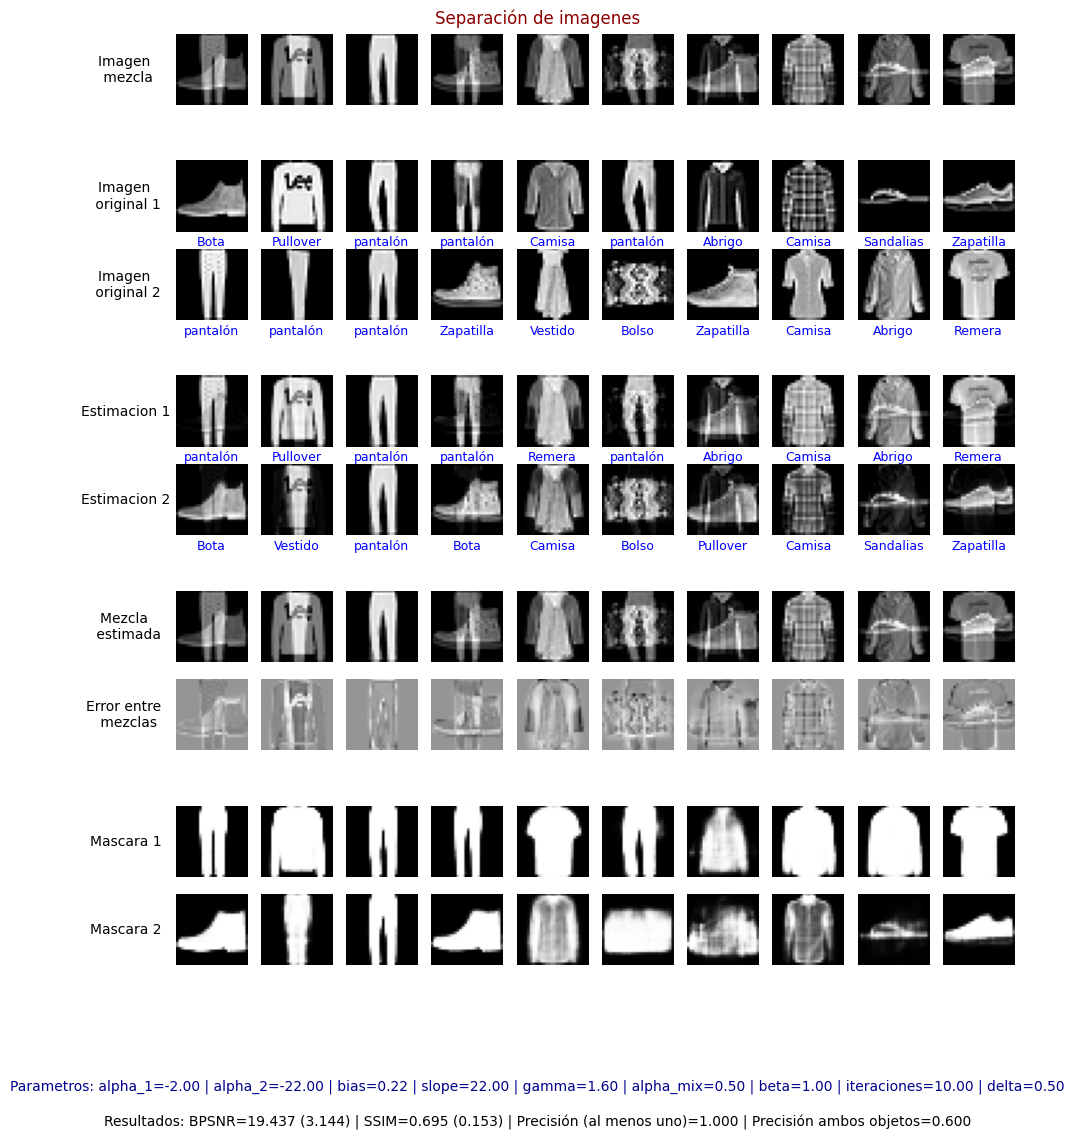

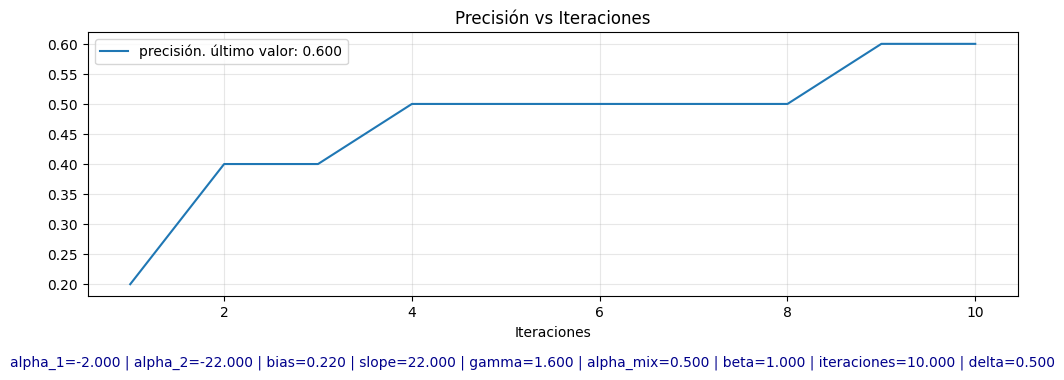

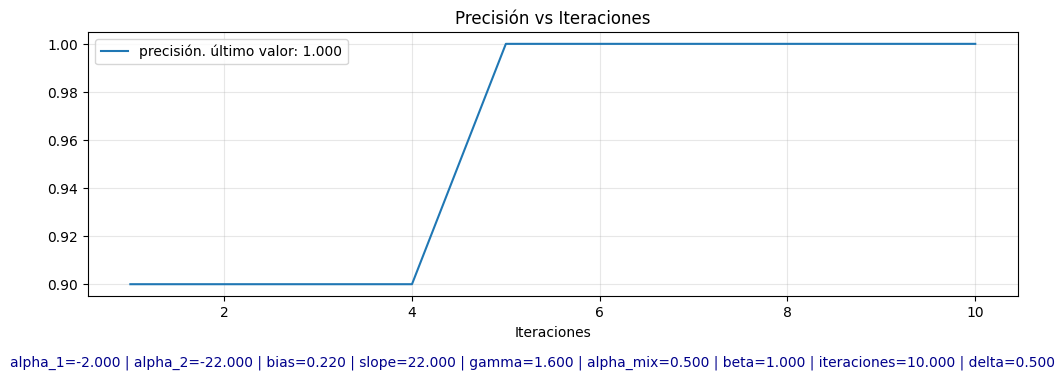

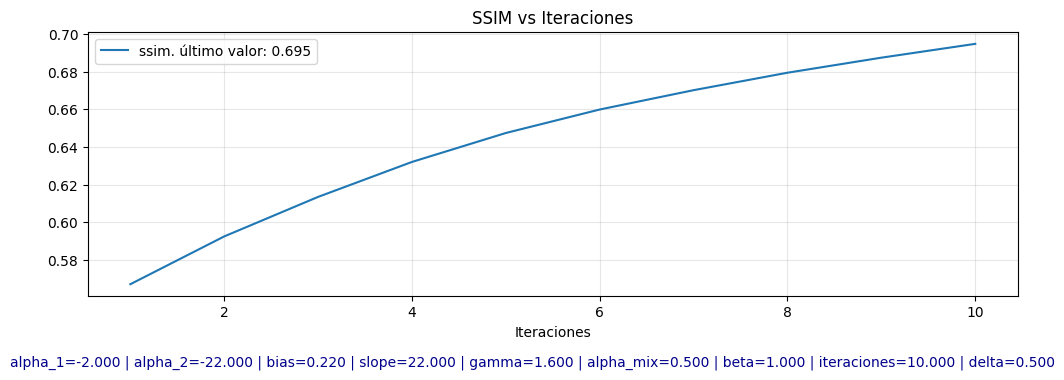

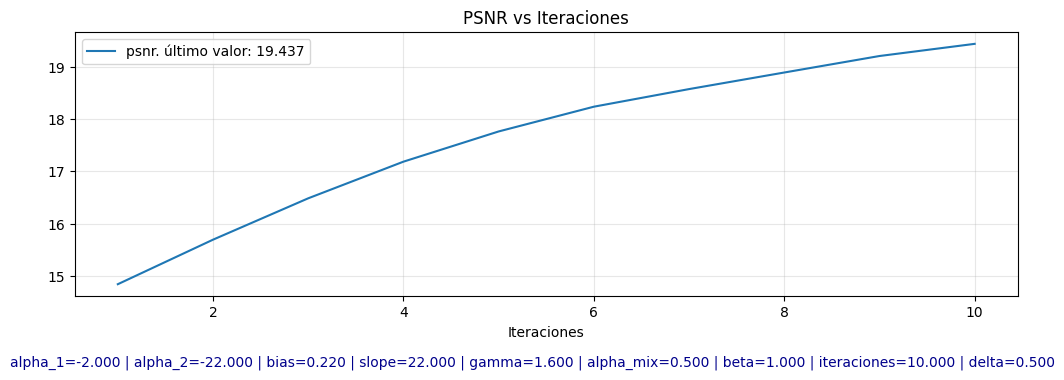


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -2.000
alpha_2     : -22.000
bias        : 0.220
slope       : 22.000
gamma       : 1.600
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.500

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 19.437  std:3.144
mask_bpsnr       : mean: 11.176  std:1.959
ssim             : mean: 0.695  std:0.153
acc_at_least_one : 1.000
acc_both         : 0.600



In [ ]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from project.CROP.models.crop_base_model import CropBaseModel
from project.custom_layers.sampling import Sampling
import tensorflow as tf
import random
from project.metrics.metrics import Metrics
import numpy as np
from project.loader import Loader

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from project.CROP.models.crop3_estimation_correction import Crop3


class Crop2(CropBaseModel):


    def _show_images(self, tensor, title="", max_images=1):
        if not hasattr(self, "debug") or not self.debug:
            return

        imgs = tensor

        if isinstance(imgs, tf.Tensor):
            imgs = imgs.numpy()

        # asegurar batch
        if len(imgs.shape) == 1:
            imgs = np.expand_dims(imgs, axis=0)

        n = min(max_images, imgs.shape[0])

        fig, axes = plt.subplots(1, n, figsize=(n * 2, 2))

        if n == 1:
            axes = [axes]

        for i in range(n):
            img = imgs[i]

            # reshape si está plano
            if len(img.shape) == 1:
                img = img.reshape(28, 28)

            max_val = np.max(img)

            axes[i].imshow(img, cmap="gray")
            axes[i].set_title(f"{title} \nmax: {max_val:.3f}", fontsize=8)
            #axes[i].set_title(f"{title}", fontsize=8)
            axes[i].axis("off")

        plt.tight_layout()
        plt.show()

    def filter(self, filter_1, filter_2 ,mixed_input, alpha, bias, slope,n_fuente,delta):

        x_mix_filter_1 =  2 * mixed_input - filter_1
        self._show_images(x_mix_filter_1, f"Estimación {n_fuente} luego de:\n 2 * mezcla - estimación 1")

        x_mix_filter_1 = tf.clip_by_value(x_mix_filter_1, 0, 1)
        self._show_images(x_mix_filter_1, f"Estimación {n_fuente} \n luego de clip")

        condition_encoder = self.predictor(x_mix_filter_1, verbose=0, training=False)
#       print(condition_encoder)
        encoded_imgs = self.cvae.encoder(
            [x_mix_filter_1, condition_encoder], verbose=0, training=0
        )
        
        zz_log_var = encoded_imgs[1] + alpha

        z = Sampling()((encoded_imgs[0], zz_log_var))

        cvae_output = self.cvae.decoder(
            [z, condition_encoder], verbose=0, Training=False
        )
        
        self._show_images(cvae_output, "Output del CVAE: \n mascara intermedia, imagen 2")

        # x__x = (self.source1_estimation+self.source2_estimation)/2
        # x__x_e = x__x - mixed_input
        # mask_source1 = mask_source1 -4.6*(x__x_e) # proto delta
        # self._show_images(x__x_e, f"Error  de mezclas  \n x__x_e - mix")

        
        
        self._show_images(cvae_output, f"Estimación {n_fuente}: \n mascara menos la correccions \n x_mix y x__x_e ")

        mask_source1 = (cvae_output - bias) * slope
        self._show_images(mask_source1, f"Máscara intermedia imagen {n_fuente} \n con bias y slope")

        mask_source1 = tf.sigmoid(mask_source1)
        self._show_images(mask_source1, "Mascara imagen 2")
        

        
        x_mix_filter_1 = 2 * mixed_input * mask_source1
        self._show_images(x_mix_filter_1, f"Estimación {n_fuente}: \n mezcla filtrada con la máscara ")

        x_mix_filter_1 = tf.clip_by_value(x_mix_filter_1, 0, 1) # raro.
        # self._show_images(x_mix_filter_1, f"Estimación {n_fuente} \n luego de clip")
        x_mix_filter_1 = x_mix_filter_1 -(x_mix_filter_1-cvae_output)*delta

        return x_mix_filter_1, mask_source1, condition_encoder



    def decode(self):
        alpha_1 = self.model_params["alpha_1"]
        alpha_2 = self.model_params["alpha_2"]
        beta = self.model_params["beta"]
        bias = self.model_params["bias"]
        slope = self.model_params["slope"]
        gamma = self.model_params["gamma"]
        delta = self.model_params["delta"]

        self._show_images(self.source1_estimation, "Estimación Imagen 1:\n Inicio de la iteración")
        self._show_images(self.source2_estimation, "Estimación Imagen 2:\n Inicio de la iteración")
        #self._show_images(self.mix_input,"Imagen mezcla.")
        reconstructed_source1, mask_source1, predictions_1 = (
            self.filter(self.source2_estimation,self.source1_estimation ,self.mixed_input, alpha_2, bias, slope,1,delta)
        )

        self.source1_estimation = reconstructed_source1
        self.mask1 = mask_source1
        self.predictions1 = predictions_1
        self.model_params["alpha_2"] = alpha_2 * beta

        x__x = (self.source1_estimation + self.source2_estimation) / 2
        x__x_e = x__x - self.mixed_input
        

        self.source1_estimation = self.source1_estimation - (x__x_e * gamma)

        self._show_images(
            self.source1_estimation,
            "Estimación 1 \n correción gamma."
        )

        self.source1_estimation = tf.clip_by_value(self.source1_estimation, 0, 1)

        self._show_images(self.source1_estimation, "Estimación 1 \n clip luego de la \n correción gamma.")

        print("\n----- estimación de la fuente complementaria -----\n")

        reconstructed_source2, mask_source2, predictions_2 = (
            self.filter(reconstructed_source1, self.source1_estimation ,self.mixed_input, alpha_1, bias, slope,2,delta)
        )

        self.source2_estimation = reconstructed_source2
        self.mask2 = mask_source2
        self.predictions2 = predictions_2
        self.model_params["alpha_1"] = alpha_1 * beta

        x__x = (self.source1_estimation + self.source2_estimation) / 2
        x__x_e = x__x - self.mixed_input

        self.source2_estimation = self.source2_estimation - (x__x_e * gamma)

        self._show_images(
            self.source2_estimation,
            "Estimación 2 \n correción gamma."
        )

        self.source2_estimation = tf.clip_by_value(self.source2_estimation, 0, 1)

        self._show_images(self.source2_estimation, "Estimación 2 \n clip luego de la \n correción gamma.")

        print("--------------------------------------- fin de la iteración ----------------------------")
        print(" ")
        print("--------------------------------------- inicio de la iteración -------------------------")
        


SEED = 1234 #Semilla
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


ITERATIONS = 10
N_PICTURES = 10

DATASET = "fashion" # mnist o fashion
LAT = 64
INTER = 128
cvae = Loader.cvae(inter=INTER,lat=LAT,dataset=DATASET)
data = Loader.data(dataset=DATASET)

predictor = Loader.predictor(dataset=DATASET)

x_test = data["x_test"]
x_test_1 = data["x_test_1"]
y_test = data["y_test"]
y_test_1 = data["y_test_1"]
labels= data["labels"]



c = Crop2(cvae=cvae,predictor=predictor)
c.debug = False


metrics = c.unmix(
    x_test[:N_PICTURES],
    x_test_1[:N_PICTURES],
    y_test[:N_PICTURES],
    y_test_1[:N_PICTURES],
    iterations=ITERATIONS,
    show_image=True,
    labels=labels,
    params={"gamma":0.33, "delta":0},
    show_all_curves=True
    )








## Cambio de regimen.
Las primeras 10 iteraciones seran con el flujo actual. Luego se utilizará otra forma de estimar. 

Usando fashion como dataset


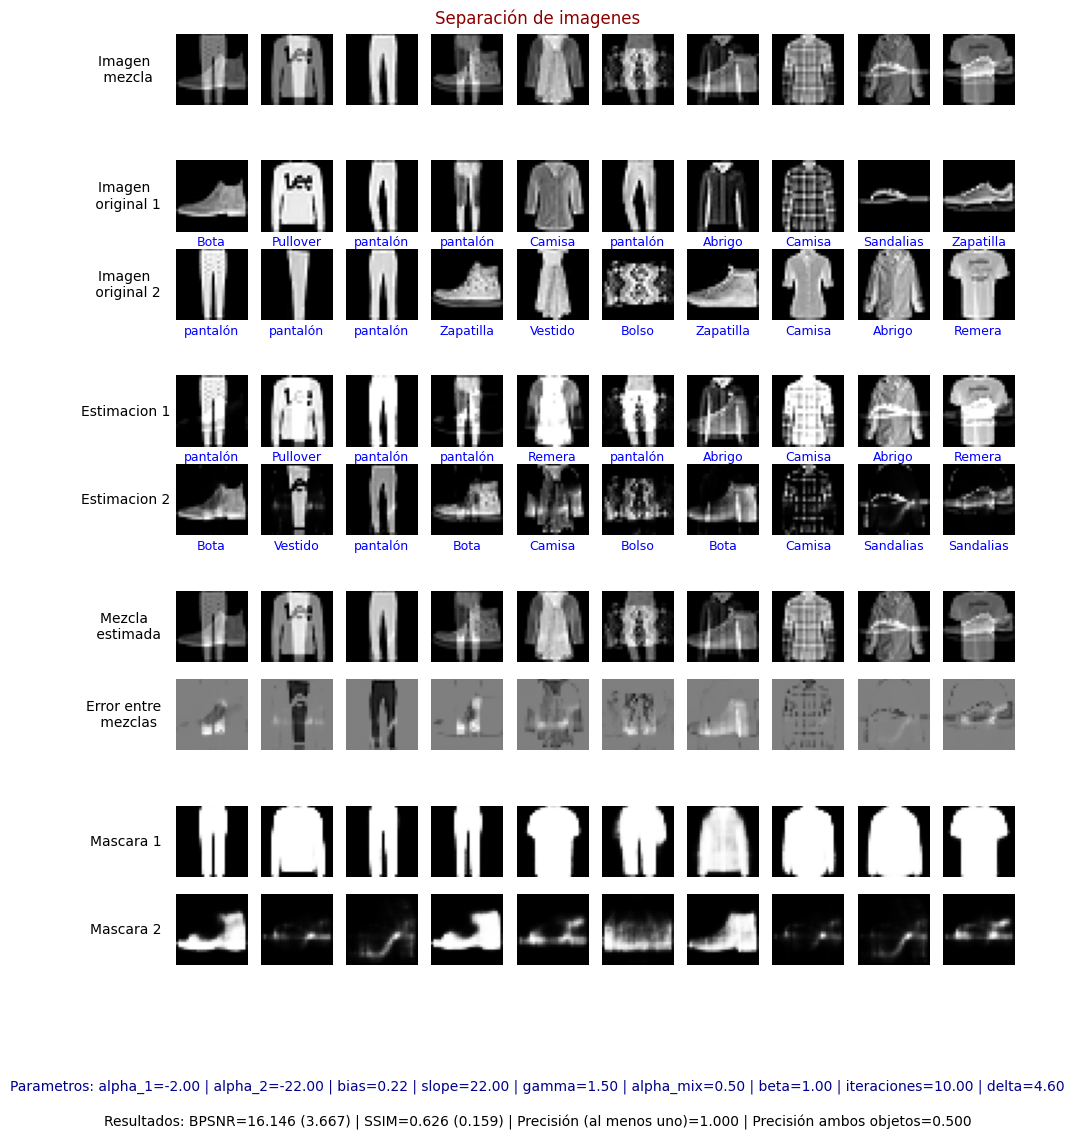

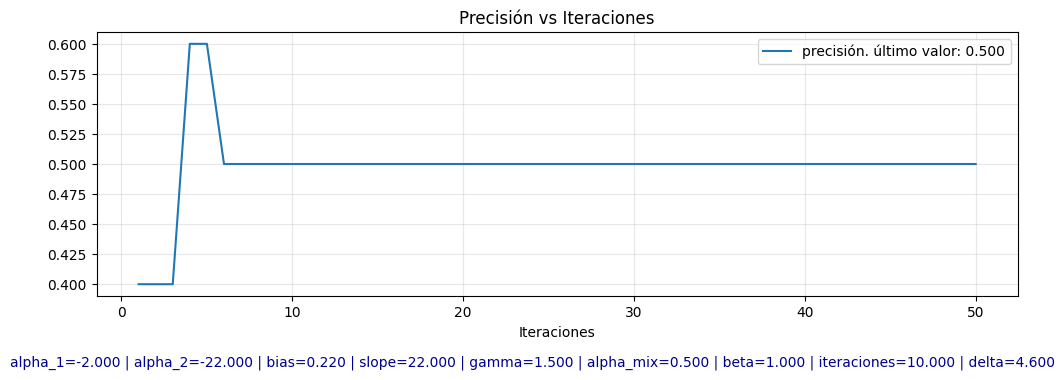

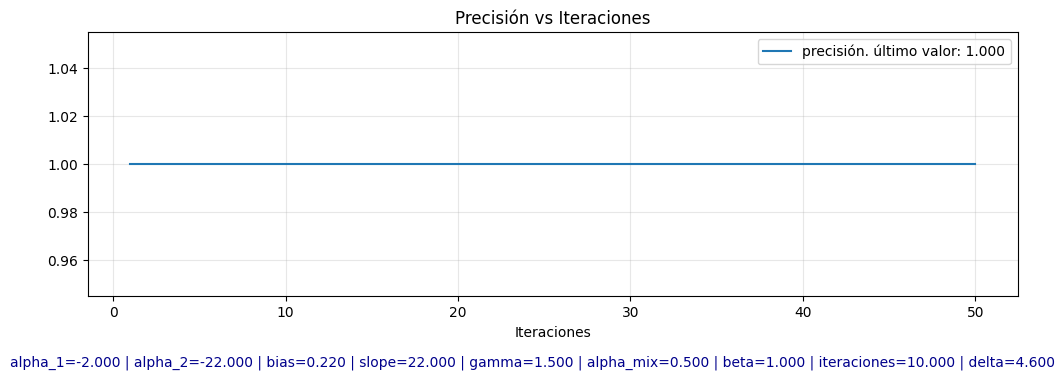

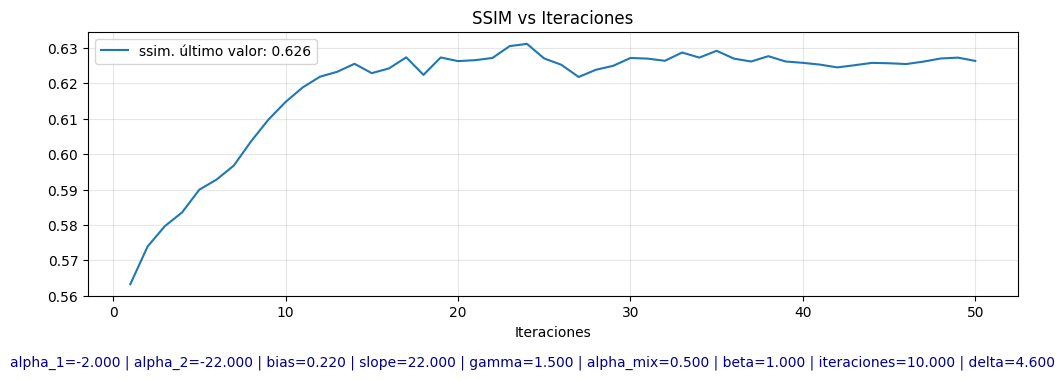

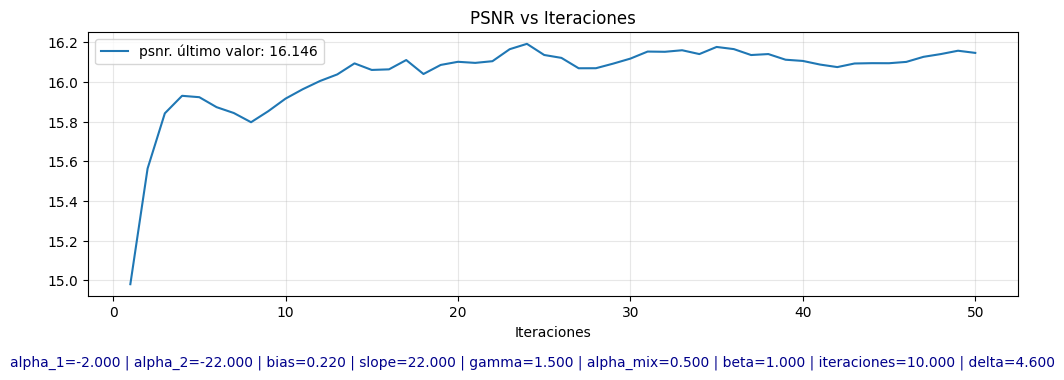


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -2.000
alpha_2     : -22.000
bias        : 0.220
slope       : 22.000
gamma       : 1.500
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 4.600

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 16.146  std:3.667
mask_bpsnr       : mean: 10.529  std:1.779
ssim             : mean: 0.626  std:0.159
acc_at_least_one : 1.000
acc_both         : 0.500



In [22]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from project.CROP.models.crop_base_model import CropBaseModel
from project.custom_layers.sampling import Sampling
import tensorflow as tf
import random
from project.metrics.metrics import Metrics
import numpy as np
from project.loader import Loader

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf


class Coprtest(CropBaseModel):


    def normalize_image(self, x, eps=1e-8):

        x = tf.convert_to_tensor(x)

        # detectar dimensiones automáticamente
        ndims = len(x.shape)

        if ndims == 4:
            axes = [1, 2, 3]

        elif ndims == 3:
            axes = [1, 2]

        elif ndims == 2:
            axes = [0, 1]

        else:
            return x

        x_min = tf.reduce_min(x, axis=axes, keepdims=True)
        x_max = tf.reduce_max(x, axis=axes, keepdims=True)

        x_norm = (x - x_min) / (x_max - x_min + eps)

        return tf.clip_by_value(x_norm, 0, 1)

    def _show_images(self, tensor, title="", max_images=1):
        if not hasattr(self, "debug") or not self.debug:
            return

        imgs = tensor

        if isinstance(imgs, tf.Tensor):
            imgs = imgs.numpy()

        # asegurar batch
        if len(imgs.shape) == 1:
            imgs = np.expand_dims(imgs, axis=0)

        n = min(max_images, imgs.shape[0])

        fig, axes = plt.subplots(1, n, figsize=(n * 2, 2))

        if n == 1:
            axes = [axes]

        for i in range(n):
            img = imgs[i]

            # reshape si está plano
            if len(img.shape) == 1:
                img = img.reshape(28, 28)

            max_val = np.max(img)
            min_val = np.min(img)
            axes[i].imshow(img, cmap="gray")
            axes[i].set_title(f"{title} \nmax: {max_val:.3f}, min: {min_val:3f} ", fontsize=8)
            #axes[i].set_title(f"{title}", fontsize=8)
            axes[i].axis("off")

        plt.tight_layout()
        plt.show()

    def filter(self, filter_1 ,mixed_input, alpha, bias, slope):

        x_mix_filter_1 =  2 * mixed_input - filter_1
        
        x_mix_filter_1 = tf.clip_by_value(x_mix_filter_1, 0, 1)

        condition_encoder = self.predictor(x_mix_filter_1, verbose=0, training=False)
        encoded_imgs = self.cvae.encoder(
            [x_mix_filter_1, condition_encoder], verbose=0, training=0
        )
        
        zz_log_var = encoded_imgs[1] + alpha

        z = Sampling()((encoded_imgs[0], zz_log_var))

        cvae_output = self.cvae.decoder(
            [z, condition_encoder], verbose=0, training=False
        )
        
        mask_source1 = (cvae_output - bias) * slope

        mask_source1 = tf.sigmoid(mask_source1)
    

        x_mix_filter_1 = 2 * mixed_input * mask_source1

        return x_mix_filter_1, mask_source1, condition_encoder

    def second_filter(self, filter_1 ,mixed_input, alpha, bias, slope,delta):
        print("second filter")
        x_mix_filter_1 =  2 * mixed_input - filter_1
        
        x_mix_filter_1 = tf.clip_by_value(x_mix_filter_1, 0, 1)

        condition_encoder = self.predictor(x_mix_filter_1, verbose=0, training=False)
        encoded_imgs = self.cvae.encoder(
            [x_mix_filter_1, condition_encoder], verbose=0, training=0
        )
        
        zz_log_var = encoded_imgs[1] + alpha

        z = Sampling()((encoded_imgs[0], zz_log_var))

        cvae_output = self.cvae.decoder(
            [z, condition_encoder], verbose=0, Training=False
        )
        
        mask_source1 = (cvae_output - bias) * slope

        mask_source1 = tf.sigmoid(mask_source1)
        
        self._show_images(mask_source1,"mask generada")
        
        mask_source1 = mask_source1 - delta*((self.source1_estimation+self.source2_estimation)/2-mixed_input)
        

        self._show_images(mask_source1, "mascara post delta ")
        
        
        self._show_images(mixed_input,"mezlca orignal")
        
        x_mix_filter_1 = 2 * mixed_input * mask_source1

        x_mix_filter_1 = tf.clip_by_value(x_mix_filter_1, 0, 1)

        self._show_images(x_mix_filter_1, "resultado de un filtrado")
            


        return x_mix_filter_1, mask_source1, condition_encoder



    def decode(self):
        alpha_1 = self.model_params["alpha_1"]
        alpha_2 = self.model_params["alpha_2"]
        beta = self.model_params["beta"]
        bias = self.model_params["bias"]
        slope = self.model_params["slope"]
        gamma = self.model_params["gamma"]
        delta = self.model_params["delta"]
        iteration = self.iteration

        if iteration<ITERATIONS: # puede ser otra valor de iter.
            reconstructed_source1, mask_source1, predictions_1 = (
                self.filter(self.source2_estimation ,self.mixed_input, alpha_2, bias, slope)
            )

            self.source1_estimation = reconstructed_source1
            self.mask1 = mask_source1
            self.predictions1 = predictions_1
            self.model_params["alpha_2"] = alpha_2 * beta

            x__x = (self.source1_estimation + self.source2_estimation) / 2
            x__x_e = x__x - self.mixed_input
            

            self.source1_estimation = self.source1_estimation - (x__x_e * gamma)

       
            self.source1_estimation = tf.clip_by_value(self.source1_estimation, 0, 1)

            reconstructed_source2, mask_source2, predictions_2 = (
                self.filter(reconstructed_source1,  self.mixed_input, alpha_1, bias, slope)
            )

            self.source2_estimation = reconstructed_source2
            self.mask2 = mask_source2
            self.predictions2 = predictions_2
            self.model_params["alpha_1"] = alpha_1 * beta

            x__x = (self.source1_estimation + self.source2_estimation) / 2
            x__x_e = x__x - self.mixed_input
            
            self.source2_estimation = self.source2_estimation - (x__x_e * gamma)

            self.source2_estimation = tf.clip_by_value(self.source2_estimation, 0, 1)
        else:
            
            #print("-----------------------Segundo Ciclo---------------")
            self._show_images(self.mask1,"mask 1")
            self._show_images(self.mask2, "mask 2")
            self._show_images(self.source1_estimation,"fuente estimada 1 inicio de iteracion")
            self._show_images(self.source2_estimation, "fuente estimada 2 inicio de iteracion")
            

            x__x = (self.source1_estimation+self.source2_estimation)/2
            mix_error = x__x - self.mixed_input
            self._show_images(mix_error, "error entre mezclas")

            reconstructed_source1, mask_source1, predictions_1 = (
                self.second_filter(self.source2_estimation ,self.mixed_input, alpha_2, bias, slope,delta)
            )

            self.source1_estimation = reconstructed_source1
            self.mask1 = mask_source1
            self.predictions1 = predictions_1
            self.model_params["alpha_2"] = alpha_2 * beta

            x__x = (self.source1_estimation + self.source2_estimation) / 2
            x__x_e = x__x - self.mixed_input
            

            self.source1_estimation = self.source1_estimation - (x__x_e * gamma)

       
            self.source1_estimation = tf.clip_by_value(self.source1_estimation, 0, 1)



            self._show_images(self.source1_estimation,"fuente estimada 1 final de iteracion")
            

            reconstructed_source2, mask_source2, predictions_2 = (
                self.second_filter(reconstructed_source1,  self.mixed_input, alpha_1, bias, slope,delta)
            )

            self.source2_estimation = reconstructed_source2
            self.mask2 = mask_source2
            self.predictions2 = predictions_2
            self.model_params["alpha_1"] = alpha_1 * beta

            x__x = (self.source1_estimation + self.source2_estimation) / 2
            x__x_e = x__x - self.mixed_input
            
            self.source2_estimation = self.source2_estimation - (x__x_e * gamma)

            self.source2_estimation = tf.clip_by_value(self.source2_estimation, 0, 1)


            self._show_images(self.source2_estimation, "fuente estimada 2 final de iteracion")
            



SEED = 1234 #Semilla
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


ITERATIONS = 50
N_PICTURES = 10

DATASET = "fashion" # mnist o fashion
LAT = 64
INTER = 128
cvae = Loader.cvae(inter=INTER,lat=LAT,dataset=DATASET)
data = Loader.data(dataset=DATASET)

predictor = Loader.predictor(dataset=DATASET)

x_test = data["x_test"]
x_test_1 = data["x_test_1"]
y_test = data["y_test"]
y_test_1 = data["y_test_1"]
labels= data["labels"]


c = Coprtest(cvae=cvae,predictor=predictor)
c.debug = True


metrics = c.unmix(
    x_test[:N_PICTURES],
    x_test_1[:N_PICTURES],
    y_test[:N_PICTURES],
    y_test_1[:N_PICTURES],
    iterations=ITERATIONS,
    show_image=True,
    labels=labels,
    params={"gamma":1.5, "delta":4.6},
    show_all_curves=True
    )








## Ultima iteración sacando el clip

In [ ]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from project.CROP.models.crop_base_model import CropBaseModel
from project.custom_layers.sampling import Sampling
import tensorflow as tf
import random
from project.metrics.metrics import Metrics
import numpy as np
from project.loader import Loader
from project.CROP.models.crop3_mask_correction import Crop3MaskCorrection
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf



class CropTest(CropBaseModel):

    def filter(self, filter_1, mixed_input, alpha,bias,slope): 
        #best_filtered_var_sigmoid

        x_mix_filter_1 = 2 * mixed_input - filter_1
        x_mix_filter_1 = tf.clip_by_value(
            x_mix_filter_1, clip_value_min=0, clip_value_max=1
        )
        condition_encoder = self.predictor(x_mix_filter_1, verbose=0, training=False)
    
        condition_decoder_1 = condition_encoder

        encoded_imgs = self.cvae.encoder(
            [x_mix_filter_1, condition_encoder], verbose=0, training=0
        )

        zz_log_var = encoded_imgs[1]  + alpha

        z = Sampling()((encoded_imgs[0], zz_log_var))

        mask_source1 = self.cvae.decoder(
            [z, condition_decoder_1], verbose=0, Training=False
        )
        mask_source1 = (mask_source1 - bias) * slope
        mask_source1 = tf.sigmoid(mask_source1)

        x_mix_filter_1 = 2 * mixed_input * mask_source1
        x_mix_filter_1 = tf.clip_by_value(
            x_mix_filter_1, clip_value_min=0, clip_value_max=1
        )

        return (x_mix_filter_1, mask_source1, condition_encoder)



    def decode(self):
        alpha_1 = self.model_params["alpha_1"]
        alpha_2 = self.model_params["alpha_2"]
        beta = self.model_params["beta"]
        bias = self.model_params["bias"]
        slope = self.model_params["slope"]
        gamma = self.model_params["gamma"]
        

        if self.iteration < ITERATIONS:
            reconstructed_source1, mask_source1, predictions_1 = (
                self.filter(self.source2_estimation, self.mixed_input, alpha_2,bias,slope)
            )
            
        
            self.source1_estimation = reconstructed_source1
            self.mask1 = mask_source1
            self.predictions1 = predictions_1 
            self.model_params["alpha_2"] = alpha_2 * beta

            x__x = (self.source1_estimation + self.source2_estimation) / 2

            x__x_e = x__x - self.mixed_input

            self.source1_estimation = self.source1_estimation - (x__x_e * gamma)

            self.source1_estimation = tf.clip_by_value(
                self.source1_estimation, clip_value_min=0, clip_value_max=1
            )

            reconstructed_source2, mask_source2, predictions_2 = (
                self.filter(
                    reconstructed_source1, self.mixed_input, alpha_1,bias,slope
                )
            )
            
            self.source2_estimation = reconstructed_source2
            self.mask2 = mask_source2
            self.predictions2 = predictions_2 
            self.model_params["alpha_1"] = alpha_1 * beta

            x__x = (self.source1_estimation + self.source2_estimation) / 2
            x__x_e = x__x - self.mixed_input

            self.source2_estimation = self.source2_estimation - (x__x_e * gamma)

            self.source2_estimation = tf.clip_by_value(
                self.source2_estimation, clip_value_min=0, clip_value_max=1
            )
        else:
            self.source2_estimation = 2 * self.mixed_input - self.source1_estimation
            self.source1_estimation =  2 * self.mixed_input  - self.source2_estimation
        
        




SEED = 1234 #Semilla
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


ITERATIONS = 30
N_PICTURES = 10

DATASET = "fashion" # mnist o fashion
LAT = 64
INTER = 128
cvae = Loader.cvae(inter=INTER,lat=LAT,dataset=DATASET)
data = Loader.data(dataset=DATASET)

predictor = Loader.predictor(dataset=DATASET)

x_test = data["x_test"]
x_test_1 = data["x_test_1"]
y_test = data["y_test"]
y_test_1 = data["y_test_1"]
labels= data["labels"]



# c = CropTest(cvae=cvae,predictor=predictor)
# c.debug = False


# metrics = c.unmix(
#     x_test[:N_PICTURES],
#     x_test_1[:N_PICTURES],
#     y_test[:N_PICTURES],
#     y_test_1[:N_PICTURES],
#     iterations=ITERATIONS,
#     show_image=True,
#     labels=labels,
#     params={"gamma":1.5},
#     show_all_curves=True
#     )

c = Crop3MaskCorrection(cvae=cvae,predictor=predictor)
c.debug = False


metrics = c.unmix(
    x_test[:N_PICTURES],
    x_test_1[:N_PICTURES],
    y_test[:N_PICTURES],
    y_test_1[:N_PICTURES],
    iterations=ITERATIONS,
    show_image=True,
    labels=labels,
    params={"gamma":1.5,"delta":0},
    show_all_curves=True
    )











Usando fashion como dataset


/home/galsan/Desktop/tesis/CROP_1/.venv/lib/python3.11/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['original_input']
Received: inputs=Tensor(shape=(10, 784))
  warnings.warn(msg)


ValueError: In a nested call() argument, you cannot mix tensors and non-tensors. Received invalid mixed argument: inputs=[array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.00392157, ..., 0.        , 0.        ,
        0.        ]], dtype=float32), <tf.Tensor: shape=(10, 10), dtype=float32, numpy=
array([[1.92728403e-05, 9.95103121e-01, 2.00359849e-04, 1.09400076e-03,
        4.04048449e-04, 4.71233870e-05, 2.03967007e-04, 9.56575153e-04,
        7.73802003e-06, 1.96389761e-03],
       [1.87337701e-03, 1.86461039e-04, 8.02384377